<a href="https://colab.research.google.com/github/yuki-matsumoto74/image_cnn_v1/blob/main/%E7%94%BB%E5%83%8F%E8%AA%8D%E8%AD%98_pytorch%EF%BC%91.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

pytorch
gpu: nvidia T4


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import cifar10

In [ ]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()
print(f'x_train shape: {x_train.shape}')
print(f'y_train shape: {y_train.shape}')

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
x_train shape: (50000, 32, 32, 3)
y_train shape: (50000, 1)


x_trainは画像本体、y_trainは正解ラベル。それぞれインデックスで対応している。

In [ ]:
num_classes = 10
pos =1

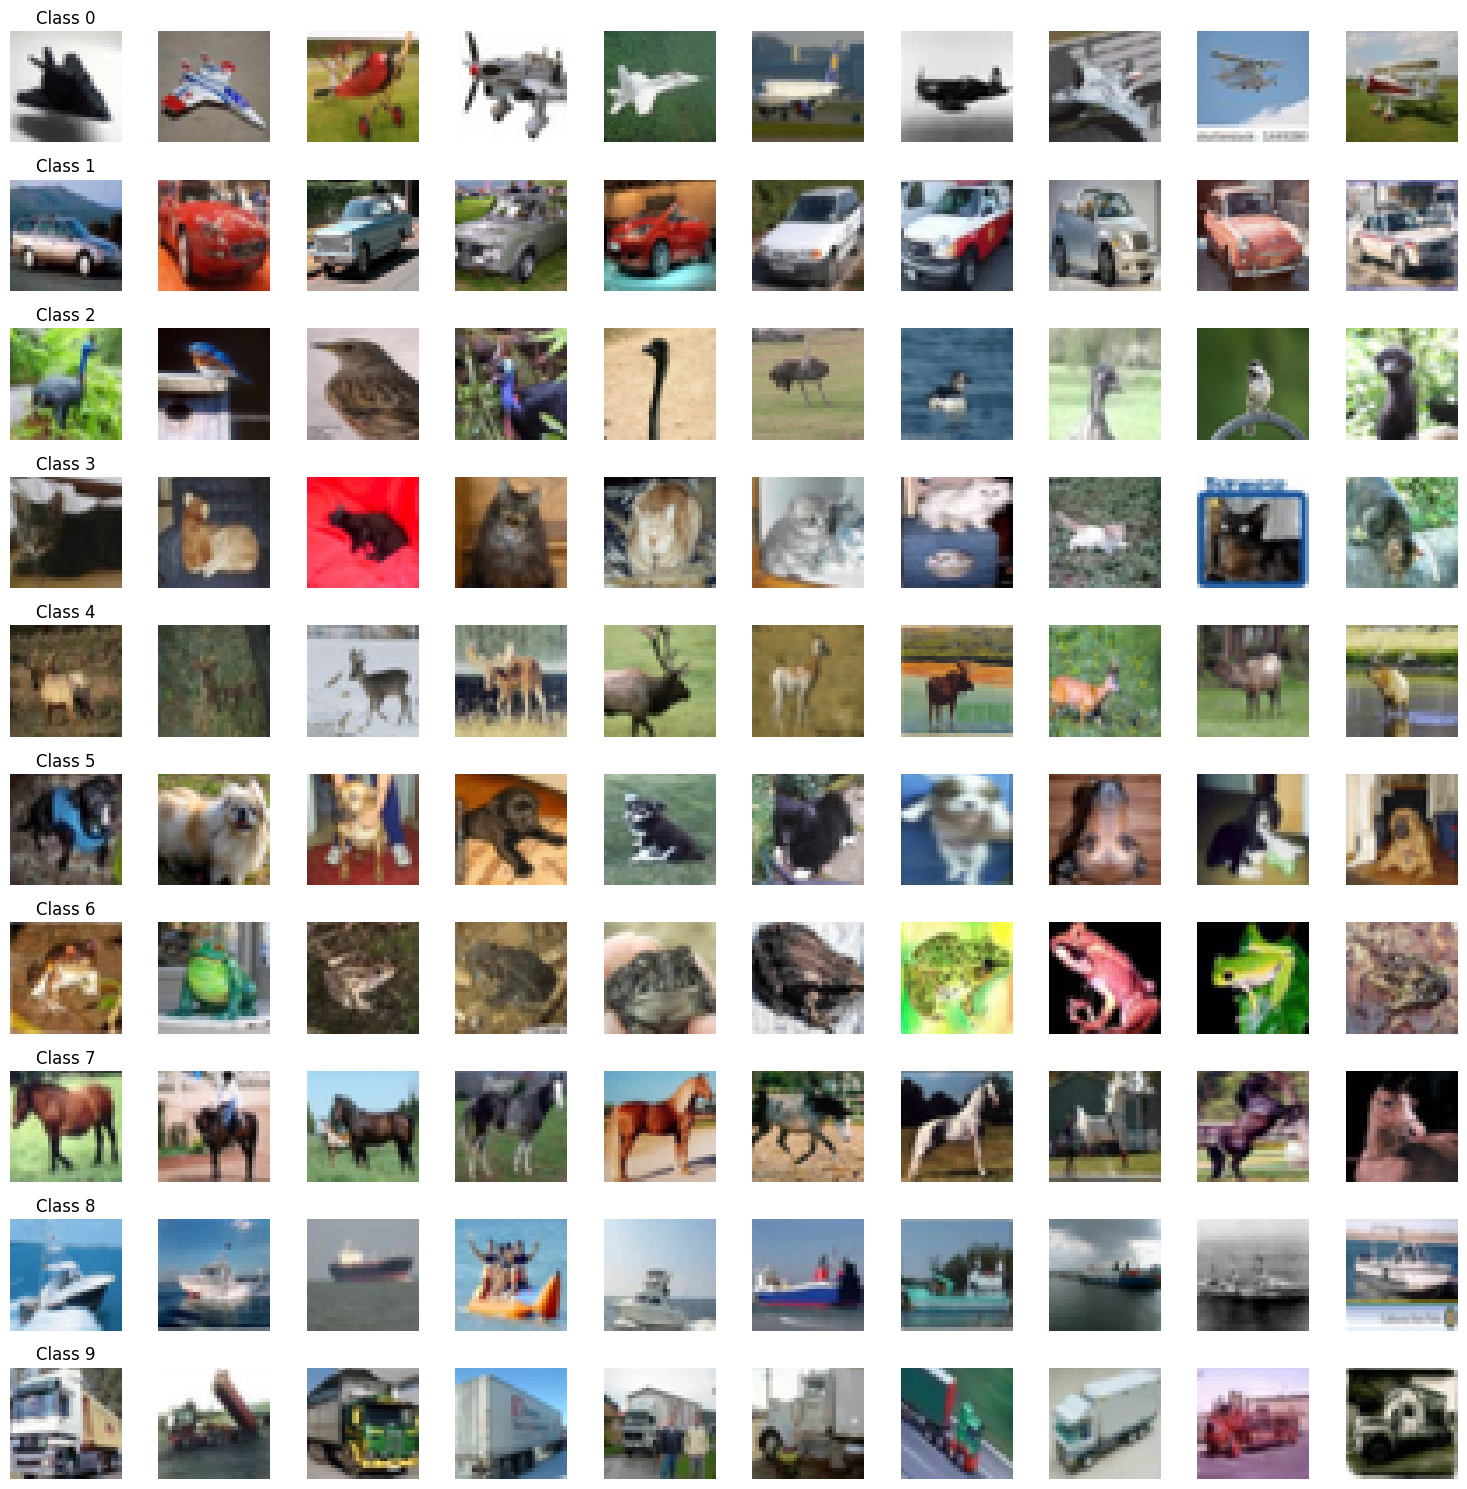

In [ ]:
plt.figure(figsize=(15, 15))

for target_class in range(num_classes):
    # y_trainを平坦化して、現在のターゲットクラスと一致するインデックスを抽出
    target_idx = np.where(y_train.flatten() == target_class)[0]
    # flatten で行列を解体している。１業の行列にしている。↑

    # 各クラスの最初の10枚をプロット
    for i in range(10):
        plt.subplot(num_classes, 10, target_class * 10 + i + 1)
        # 正解ラベルのインデックスに基づいて画像を取得
        img_idx = target_idx[i]
        plt.imshow(x_train[img_idx])
        plt.axis('off')
        if i == 0:
            plt.title(f'Class {target_class}')

plt.tight_layout()
plt.show()

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'gpuじゃなくてcpu')
print(device)

cuda


In [ ]:

# CNNモデル定義
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.pool1 = nn.MaxPool2d(2, 2)
        self.dropout1 = nn.Dropout2d(0.25)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool2 = nn.MaxPool2d(2, 2)
        self.dropout2 = nn.Dropout2d(0.25)
        self.conv3 = nn.Conv2d(64, 64, kernel_size=3, padding=1)
        self.pool3 = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(64 * 4 * 4, 128)
        self.dropout3 = nn.Dropout(0.5)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.dropout1(self.pool1(F.relu(self.conv1(x))))
        x = self.dropout2(self.pool2(F.relu(self.conv2(x))))
        x = self.pool3(F.relu(self.conv3(x)))
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = self.dropout3(x)
        x = self.fc2(x)
        return x

# デバイスの設定
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# モデルのインスタンス化とデバイスへの転送
model = SimpleCNN().to(device)

# オプティマイザの定義（モデルを移動した後に実行する必要があります）
optimizer = optim.Adam(model.parameters())
criterion = nn.CrossEntropyLoss()

print(f'Using device: {device}')
print(model)

Using device: cuda
SimpleCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout1): Dropout2d(p=0.25, inplace=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout2): Dropout2d(p=0.25, inplace=False)
  (conv3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=1024, out_features=128, bias=True)
  (dropout3): Dropout(p=0.5, inplace=False)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)


In [ ]:
from torch.utils.data import DataLoader, TensorDataset, random_split

# 1. データの準備
x_train_pt = torch.FloatTensor(x_train).transpose(1, 3).transpose(2, 3) / 255.0
y_train_pt = torch.LongTensor(y_train.flatten())
full_dataset = TensorDataset(x_train_pt, y_train_pt)
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)

# 2. 学習設定
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

epochs = 80
patience = 5
best_loss = float('inf')
counter = 0

# 履歴を保存する辞書
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

for epoch in range(epochs):
    # --- 訓練フェーズ ---
    model.train()
    running_loss, correct_train, total_train = 0.0, 0, 0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    # --- 検証フェーズ ---
    model.eval()
    val_loss, correct_val, total_val = 0.0, 0, 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()

    # メトリクスの計算と保存
    avg_train_loss = running_loss / len(train_loader)
    avg_val_loss = val_loss / len(val_loader)
    train_acc = 100 * correct_train / total_train
    val_acc = 100 * correct_val / total_val

    history['train_loss'].append(avg_train_loss)
    history['val_loss'].append(avg_val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    print(f'Epoch {epoch + 1}/{epochs} | Train Loss: {avg_train_loss:.3f} | Val Loss: {avg_val_loss:.3f} | Val Acc: {val_acc:.2f}%')

    if avg_val_loss < best_loss:
        best_loss = avg_val_loss
        counter = 0
    else:
        counter += 1
        if counter >= patience:
            print('早期終了しました。')
            break

Epoch 1/80 | Train Loss: 1.865 | Val Loss: 1.510 | Val Acc: 45.36%
Epoch 2/80 | Train Loss: 1.579 | Val Loss: 1.421 | Val Acc: 47.83%
Epoch 3/80 | Train Loss: 1.457 | Val Loss: 1.257 | Val Acc: 54.89%
Epoch 4/80 | Train Loss: 1.360 | Val Loss: 1.169 | Val Acc: 57.89%
Epoch 5/80 | Train Loss: 1.287 | Val Loss: 1.107 | Val Acc: 61.41%
Epoch 6/80 | Train Loss: 1.227 | Val Loss: 1.071 | Val Acc: 61.50%
Epoch 7/80 | Train Loss: 1.182 | Val Loss: 1.011 | Val Acc: 65.06%
Epoch 8/80 | Train Loss: 1.144 | Val Loss: 0.978 | Val Acc: 66.01%
Epoch 9/80 | Train Loss: 1.106 | Val Loss: 0.959 | Val Acc: 66.51%
Epoch 10/80 | Train Loss: 1.083 | Val Loss: 0.970 | Val Acc: 65.57%
Epoch 11/80 | Train Loss: 1.056 | Val Loss: 0.930 | Val Acc: 67.83%
Epoch 12/80 | Train Loss: 1.040 | Val Loss: 0.903 | Val Acc: 68.92%
Epoch 13/80 | Train Loss: 1.017 | Val Loss: 0.893 | Val Acc: 68.98%
Epoch 14/80 | Train Loss: 1.000 | Val Loss: 0.877 | Val Acc: 69.13%
Epoch 15/80 | Train Loss: 0.977 | Val Loss: 0.866 | Val A

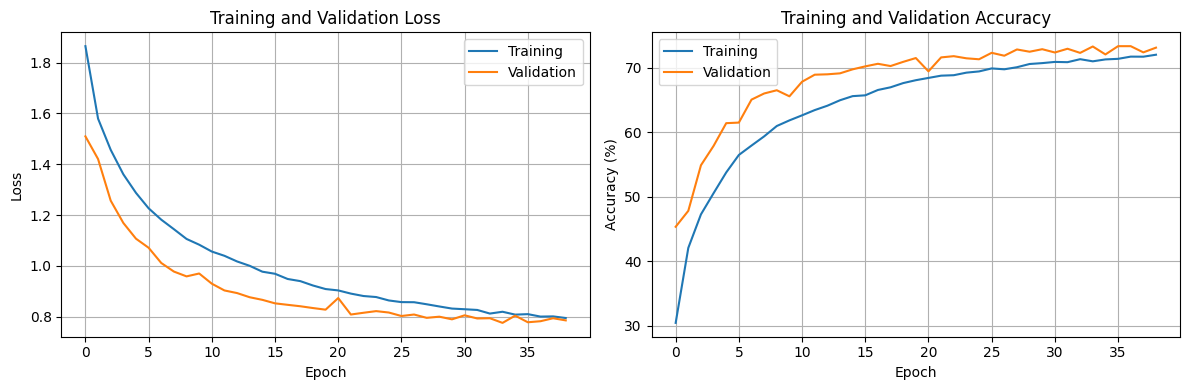

In [ ]:
import matplotlib.pyplot as plt

# Plot Loss and Accuracy
plt.figure(figsize=(12, 4))

# Loss Plot
plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Training')
plt.plot(history['val_loss'], label='Validation')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Accuracy Plot
plt.subplot(1, 2, 2)
plt.plot(history['train_acc'], label='Training')
plt.plot(history['val_acc'], label='Validation')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

損失関数がtraning, val　で両方同じように減っているから過学習の心配はない

In [ ]:
# 1. テストデータの準備
x_test_pt = torch.FloatTensor(x_test).transpose(1, 3).transpose(2, 3) / 255.0
y_test_pt = torch.LongTensor(y_test.flatten())

test_dataset = TensorDataset(x_test_pt, y_test_pt)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

# 2. モデルをデバイスに移動して評価モードに設定
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)
model.eval()

correct = 0
total = 0

# 勾配計算を無効化して推論を実行
with torch.no_grad():
    for inputs, labels in test_loader:
        # データをデバイスに移動
        inputs, labels = inputs.to(device), labels.to(device)

        outputs = model(inputs)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print(f'テストデータに対する正解率: {accuracy:.2f} %')

テストデータに対する正解率: 73.21 %


# データ拡張を使って精度を向上させる



1. 過学習を防ぐ

同じ画像でも少しずつ違うバージョンで学習
モデルが訓練データを丸暗記するのを防ぐ

2. 汎化性能を向上

回転・反転・ズームなど様々なバリエーションを学習
テストデータや実環境での未知の画像にも対応できる


3. 少ないデータでも高精度

データ収集が難しい分野(医療画像など)で特に有効
数百枚のデータでも数千枚相当の効果

4. ロバスト性の向上

ノイズ・ぼかし・色変化に強くなる
現実の不完全な画像でも正しく判定できる

In [28]:
import torch
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
from tensorflow.keras.datasets import cifar10
import numpy as np

# データの読み込み
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

# 1. データ拡張（Data Augmentation）の定義
# 【ポイント】PyTorchのデータ拡張は、Datasetの長さ（__len__）を増やすのではなく、
# __getitem__ が呼ばれるたびにランダムな加工をリアルタイムで適用。
# これにより、エポックごとに「少しずつ違う画像」が生成される。
train_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.RandomCrop(32, padding=4), # 毎回異なる位置で切り抜き
    transforms.RandomHorizontalFlip(),    # 50%の確率で反転
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])

test_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])

class CIFAR10Dataset(Dataset):
    def __init__(self, data, labels, transform=None):
        self.data = data
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        image = self.data[idx]
        label = self.labels[idx]
        if self.transform:
            # ここでランダムな加工が実行され（呼び出すたびに結果が変わる）
            image = self.transform(image)
        return image, label

# 2. データセットとデータローダーの準備
total_train_size = len(x_train)
train_indices = list(range(int(0.8 * total_train_size)))
val_indices = list(range(int(0.8 * total_train_size), total_train_size))

train_dataset = CIFAR10Dataset(x_train[train_indices], y_train.flatten()[train_indices], transform=train_transform)
val_dataset = CIFAR10Dataset(x_train[val_indices], y_train.flatten()[val_indices], transform=test_transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)



In [ ]:
print(x_train.shape) # データのshape自体は変わらない

(50000, 32, 32, 3)


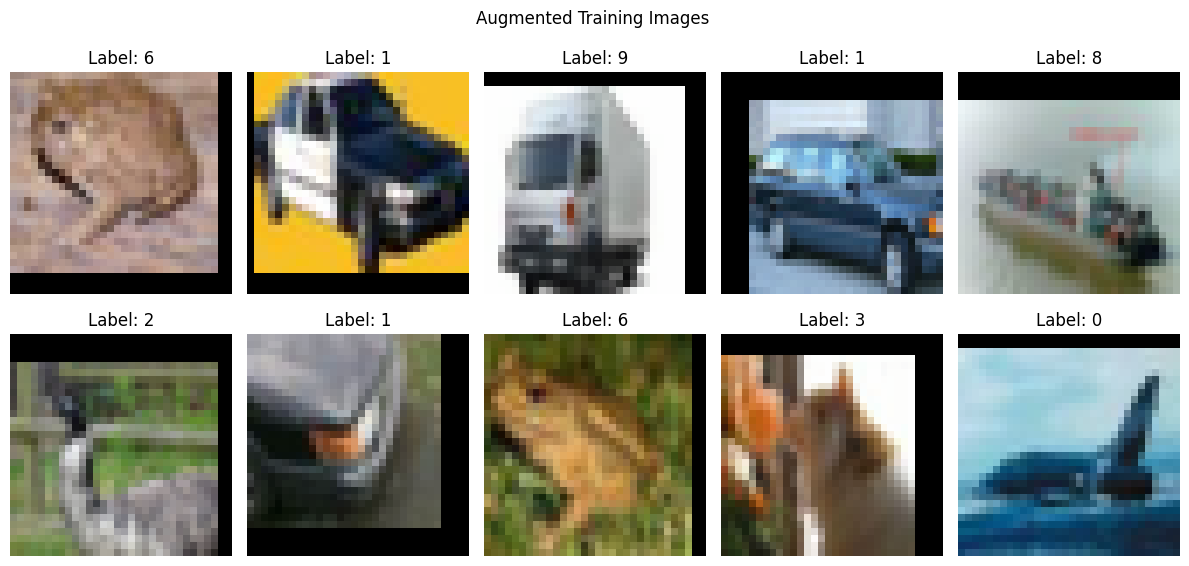

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# データローダーから1バッチ分取得
images, labels = next(iter(train_loader))

# 表示用に正規化を解除（Normalizeの逆操作）
# mean=[0.4914, 0.4822, 0.4465], std=[0.2023, 0.1994, 0.2010]
mean = np.array([0.4914, 0.4822, 0.4465])
std = np.array([0.2023, 0.1994, 0.2010])

plt.figure(figsize=(12, 6))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    # [C, H, W] -> [H, W, C] に変換し、正規化を戻す
    img = images[i].numpy().transpose((1, 2, 0))
    img = std * img + mean
    img = np.clip(img, 0, 1)

    plt.imshow(img)
    plt.title(f"Label: {labels[i].item()}")
    plt.axis('off')

plt.suptitle("Augmented Training Images ")
plt.tight_layout()
plt.show()

データ拡張では１エポックごとにランダムにデータ変換が行われる。

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

# CNNモデルの定義を再掲
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.pool1 = nn.MaxPool2d(2, 2)
        self.dropout1 = nn.Dropout2d(0.25)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool2 = nn.MaxPool2d(2, 2)
        self.dropout2 = nn.Dropout2d(0.25)
        self.conv3 = nn.Conv2d(64, 64, kernel_size=3, padding=1)
        self.pool3 = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(64 * 4 * 4, 128)
        self.dropout3 = nn.Dropout(0.5)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.dropout1(self.pool1(F.relu(self.conv1(x))))
        x = self.dropout2(self.pool2(F.relu(self.conv2(x))))
        x = self.pool3(F.relu(self.conv3(x)))
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = self.dropout3(x)
        x = self.fc2(x)
        return x

# デバイスの設定
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# モデルの初期化
model = SimpleCNN().to(device)

# 損失関数とオプティマイザの設定
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 学習の設定
epochs = 80
patience = 10
best_loss = float('inf')
counter = 0
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

print("Starting training with 学習率=0.001...")

for epoch in range(epochs):
    # --- 訓練フェーズ ---
    model.train()
    running_loss, correct_train, total_train = 0.0, 0, 0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    # --- 検証フェーズ ---
    model.eval()
    val_loss, correct_val, total_val = 0.0, 0, 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()

    # メトリクス計算
    avg_train_loss = running_loss / len(train_loader)
    avg_val_loss = val_loss / len(val_loader)
    train_acc = 100 * correct_train / total_train
    val_acc = 100 * correct_val / total_val

    history['train_loss'].append(avg_train_loss)
    history['val_loss'].append(avg_val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    print(f'Epoch {epoch + 1}/{epochs} | Train Loss: {avg_train_loss:.3f} | Val Loss: {avg_val_loss:.3f} | Val Acc: {val_acc:.2f}%')

    # 早期終了判定
    if avg_val_loss < best_loss:
        best_loss = avg_val_loss
        counter = 0
        best_model_state = model.state_dict()
    else:
        counter += 1
        if counter >= patience:
            print(f'Early stopping at epoch {epoch+1}')
            break

model.load_state_dict(best_model_state)
print("Training finished.")

Starting training with 学習率=0.01...
Epoch 1/80 | Train Loss: 1.894 | Val Loss: 1.535 | Val Acc: 44.14%
Epoch 2/80 | Train Loss: 1.652 | Val Loss: 1.390 | Val Acc: 49.93%
Epoch 3/80 | Train Loss: 1.539 | Val Loss: 1.303 | Val Acc: 53.81%
Epoch 4/80 | Train Loss: 1.466 | Val Loss: 1.199 | Val Acc: 57.93%
Epoch 5/80 | Train Loss: 1.393 | Val Loss: 1.114 | Val Acc: 59.81%
Epoch 6/80 | Train Loss: 1.348 | Val Loss: 1.059 | Val Acc: 62.69%
Epoch 7/80 | Train Loss: 1.309 | Val Loss: 1.014 | Val Acc: 63.95%
Epoch 8/80 | Train Loss: 1.271 | Val Loss: 0.974 | Val Acc: 65.58%
Epoch 9/80 | Train Loss: 1.244 | Val Loss: 0.939 | Val Acc: 66.80%
Epoch 10/80 | Train Loss: 1.222 | Val Loss: 0.923 | Val Acc: 68.09%
Epoch 11/80 | Train Loss: 1.200 | Val Loss: 0.897 | Val Acc: 68.83%
Epoch 12/80 | Train Loss: 1.191 | Val Loss: 0.880 | Val Acc: 69.18%
Epoch 13/80 | Train Loss: 1.172 | Val Loss: 0.890 | Val Acc: 69.51%
Epoch 14/80 | Train Loss: 1.151 | Val Loss: 0.866 | Val Acc: 69.65%
Epoch 15/80 | Train Lo

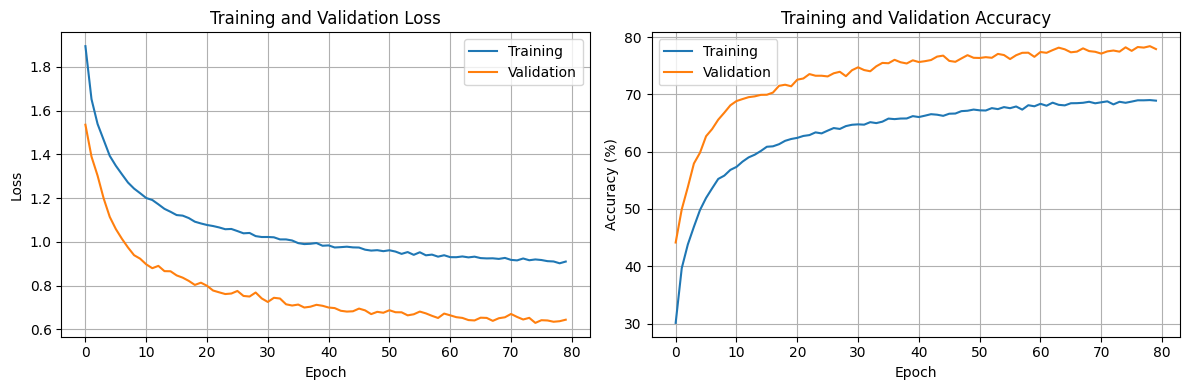

In [ ]:
import matplotlib.pyplot as plt

# Plot Loss and Accuracy
plt.figure(figsize=(12, 4))

# Loss Plot
plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Training')
plt.plot(history['val_loss'], label='Validation')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Accuracy Plot
plt.subplot(1, 2, 2)
plt.plot(history['train_acc'], label='Training')
plt.plot(history['val_acc'], label='Validation')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
# 1. テストデータセットの準備 (正規化のみ適用)
test_dataset = CIFAR10Dataset(x_test, y_test.flatten(), transform=test_transform)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

# 2. モデルを評価モードに設定
model.eval()
correct = 0
total = 0

# 勾配計算を無効化して推論
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

# 正解率の計算
test_accuracy = 100 * correct / total
print(f'テストデータ {total} 枚に対する最終的な正解率: {test_accuracy:.2f} %')

テストデータ 10000 枚に対する最終的な正解率: 77.14 %


データ拡張を使うことで、4%の精度向上ができた